In [13]:
import numpy as np
import numba as nb
import math
from time import perf_counter
import matplotlib.pyplot as plt

from gridcp import (
    OnlineChangepointDetector,
    make_univariate_mean_change_detector,
    make_univariate_variance_change_detector,
    make_univariate_mean_or_variance_change_detector,
    make_multivariate_mean_change_detector,
    make_multivariate_mean_or_covariance_change_detector,
    make_regression_change_detector,
)
from gridcp.utils import fastlog
from gridcp.calibration import draw_samples, mc_max_statistics
from gridcp import builtins
from gridcp.builtins import gen_gaussian_regression_obs

# General LR/GLR implementation for exponential families

**Primary goal:** Implement a **general** LR/GLR changepoint detector for exponential families, where the detector score function `f` computes MLEs numerically.

For a canonical exponential family $p(y|\theta)=\exp(\theta^\top h(y)-A(\theta))$, the GLR statistic is
$$\Lambda_g = \ell(\hat\theta_1;\text{seg}_1)+\ell(\hat\theta_2;\text{seg}_2)-\ell(\hat\theta_0;\text{all}).$$

The design problem is to choose the most efficient and robust **general solver** for MLE inside `f`:
1. Newton
2. L-BFGS (reference, SciPy/Python path)
3. Gradient Descent

After that, we compare against hard-coded exact solvers for known families only as baselines.

## 1. General GLR framework for exponential families

The test is fixed; only MLE computation changes:
$$\Lambda = \ell(\hat\theta_1; \text{pre}) + \ell(\hat\theta_2; \text{post}) - \ell(\hat\theta_0; \text{all}).$$

This notebook first builds general numerical solvers for $\hat\theta$ and then benchmarks exact closed-form implementations (when available) as baselines.

### 1.1 Exponential family definitions

We define two example families: **Gaussian** ($\theta = \mu$, $A(\theta)=\theta^2/2$, $h(y)=y$) and **Bernoulli** ($\theta = \text{logit}(p)$, $A(\theta) = \log(1+e^\theta)$, $h(y)=y$).

For each we provide: $h$, $A$, $\nabla A$, $\nabla^2 A$, the inverse link $(\nabla A)^{-1}$, a log-likelihood function, and a penalty.

In [6]:
# =====================================================================
# Exponential family definitions — Gaussian & Bernoulli
# =====================================================================

# ─── Gaussian (known variance σ²=1) ────────────────────────────────
# Natural parameter θ = μ, h(y) = y, A(θ) = θ²/2

V_GAUSS = 1

@nb.njit
def h_gauss(y):
    return y

@nb.njit
def A_gauss(theta):
    """Log-partition for N(θ,1): A(θ) = θ²/2."""
    return 0.5 * np.dot(theta, theta)

@nb.njit
def grad_A_gauss(theta):
    """∇A(θ) = θ."""
    return theta.copy()

@nb.njit
def hess_A_gauss(theta):
    """∇²A(θ) = I."""
    v = theta.shape[0]
    return np.eye(v)

@nb.njit
def grad_A_inv_gauss(mu):
    """Inverse link for Gaussian: identity."""
    return mu.copy()

@nb.njit
def loglik_gauss(theta, S, n):
    """ℓ(θ) = θᵀS − n·A(θ) for Gaussian."""
    return np.dot(theta, S) - n * A_gauss(theta)

# ─── Bernoulli ─────────────────────────────────────────────────────
# Natural parameter θ = logit(p), h(y) = y, A(θ) = log(1+eθ)

V_BERN = 1

@nb.njit
def h_bern(y):
    """Sufficient statistic for Bernoulli: h(y) = y."""
    return y

@nb.njit
def A_bern(theta):
    """Log-partition for Bernoulli: A(θ) = log(1 + exp(θ))."""
    return np.log(1.0 + np.exp(theta)).sum()

@nb.njit
def grad_A_inv_bern(mu):
    """Inverse link (logit): θ = log(μ/(1−μ))."""
    return np.log(mu / (1.0 - mu))

@nb.njit
def grad_A_bern(theta):
    """∇A = sigmoid(θ)."""
    ee = np.exp(theta)
    return ee / (1.0 + ee)

@nb.njit
def hess_A_bern(theta):
    """∇²A for Bernoulli."""
    ee = np.exp(theta)
    H = np.zeros((1, 1), dtype=np.float64)
    H[0, 0] = (ee / ((1.0 + ee) ** 2)).sum()
    return H

@nb.njit
def loglik_bern(theta, S, n):
    """ℓ(θ) = θᵀS − n·A(θ) for Bernoulli."""
    return np.dot(theta, S) - n * A_bern(theta)

# ─── Penalty functions (same for all MLE methods) ─────────────────

@nb.njit
def penalty_glr_gauss(pos, t, p):
    logt = fastlog(t)
    return math.sqrt(V_GAUSS * logt) + logt

@nb.njit
def penalty_glr_bern(g, t, p):
    logt = fastlog(t)
    return math.sqrt(V_BERN * logt) + logt

print("Exponential family definitions compiled.")

Exponential family definitions compiled.


### 1.2 Exact baselines (for known families only)

These closed-form MLE implementations are included as **reference baselines** for distributions where $(\nabla A)^{-1}$ is explicit:
- **Gaussian:** $\hat\theta = S/n$
- **Bernoulli:** $\hat\theta = \mathrm{logit}(S/n)$

In [7]:
# =====================================================================
# Closed-form MLE — when (∇A)⁻¹ is available analytically
# =====================================================================

EPS = 1e-8  # clamping for boundary cases

# ─── Gaussian: θ̂ = S/n (sample mean = natural parameter) ─────────

@nb.njit
def closed_form_mle_gauss(S, n):
    return S / n

@nb.njit
def f_glr_gauss(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Gaussian using closed-form MLE."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_gauss(S_all, t)
    theta1 = closed_form_mle_gauss(sum_pre_j, n1)
    theta2 = closed_form_mle_gauss(sum_post_j, n2)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

# ─── Bernoulli: θ̂ = logit(S/n) ───────────────────────────────────

@nb.njit
def closed_form_mle_bern(S, n):
    """MLE via inverse link: θ̂ = (∇A)⁻¹(S/n) = logit(S/n)."""
    mu = S / n
    for i in range(mu.shape[0]):
        if mu[i] < EPS:
            mu[i] = EPS
        elif mu[i] > 1.0 - EPS:
            mu[i] = 1.0 - EPS
    return grad_A_inv_bern(mu)

@nb.njit
def f_glr_bern(sum_pre_j, sum_post_j, pos, t):
    """GLR statistic for Bernoulli using closed-form MLE."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta0 = closed_form_mle_bern(S_all, t)
    theta1 = closed_form_mle_bern(sum_pre_j, n1)
    theta2 = closed_form_mle_bern(sum_post_j, n2)
    ll0 = loglik_bern(theta0, S_all, t)
    ll1 = loglik_bern(theta1, sum_pre_j, n1)
    ll2 = loglik_bern(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

print("Closed-form MLEs compiled.")

Closed-form MLEs compiled.


### 1.3 General solver candidate A: Newton

Newton solves the score equation $\nabla A(\theta)=S/n$ and is the primary candidate for the default general implementation when Hessians are available and well-conditioned.

In [8]:
# =====================================================================
# Solving the score equation via Newton's method
# =====================================================================
# For v=1: scalar root-finding on A'(θ) = S/n  (fast, no arrays)
# For any v: array-based Newton on ∇A(θ) = S/n  (slower, needs Hessian)

# ─── Scalar A, A', A'' for v=1 Newton ────────────────────────────

# Gaussian
@nb.njit
def A_scalar_gauss(theta):
    return 0.5 * theta * theta

@nb.njit
def A_prime_gauss(theta):
    return theta

@nb.njit
def A_dprime_gauss(theta):
    return 1.0

# Bernoulli
@nb.njit
def A_scalar_bern(theta):
    if theta > 30.0:
        return theta
    if theta < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(theta))

@nb.njit
def A_prime_bern(theta):
    if theta > 30.0:
        return 1.0
    if theta < -30.0:
        return 0.0
    e = math.exp(theta)
    return e / (1.0 + e)

@nb.njit
def A_dprime_bern(theta):
    if abs(theta) > 30.0:
        return 0.0
    e = math.exp(theta)
    s = e / (1.0 + e)
    return s * (1.0 - s)

# ─── Generic scalar Newton MLE ───────────────────────────────────

@nb.njit
def scalar_newton_mle(S_scalar, n, theta_init, A_prime, A_dprime, tol=1e-8, max_iter=20):
    """Scalar Newton to solve A'(θ̂) = S/n.
    Pure scalar arithmetic, zero allocations."""
    theta = theta_init
    target = S_scalar / n
    for _ in range(max_iter):
        ap = A_prime(theta)
        residual = ap - target
        if abs(residual) < tol:
            return theta
        adp = A_dprime(theta)
        if adp < 1e-15:
            return theta
        theta = theta - residual / adp
    return theta

@nb.njit
def scalar_loglik(theta, S_scalar, n, A_scalar):
    """Scalar log-likelihood θ·S − n·A(θ)."""
    return theta * S_scalar - n * A_scalar(theta)

# ─── Gaussian: scalar Newton GLR ─────────────────────────────────

@nb.njit
def f_glr_gauss_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Gaussian v=1."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre, s_post = sum_pre_j[0], sum_post_j[0]
    s_all = s_pre + s_post
    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_gauss, A_dprime_gauss)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_gauss, A_dprime_gauss)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_gauss, A_dprime_gauss)
    ll0 = scalar_loglik(th0, s_all, t, A_scalar_gauss)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_gauss)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_gauss)
    return ll1 + ll2 - ll0

# ─── Bernoulli: scalar Newton GLR ────────────────────────────────

@nb.njit
def f_glr_bern_scalar_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with scalar Newton for Bernoulli v=1."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    s_pre, s_post = sum_pre_j[0], sum_post_j[0]
    s_all = s_pre + s_post
    th0 = scalar_newton_mle(s_all, t, 0.0, A_prime_bern, A_dprime_bern)
    th1 = scalar_newton_mle(s_pre, n1, th0, A_prime_bern, A_dprime_bern)
    th2 = scalar_newton_mle(s_post, n2, th0, A_prime_bern, A_dprime_bern)
    ll0 = scalar_loglik(th0, s_all, t, A_scalar_bern)
    ll1 = scalar_loglik(th1, s_pre, n1, A_scalar_bern)
    ll2 = scalar_loglik(th2, s_post, n2, A_scalar_bern)
    return ll1 + ll2 - ll0

# ─── Array-based Newton (slow baseline, any v) ───────────────────
# Uses np.linalg.solve + Hessian.  Included for completeness.

@nb.njit
def newton_mle_gauss(S, n, theta_init, tol=1e-12, max_iter=100):
    """Array-based Newton MLE for Gaussian (slow baseline)."""
    theta = theta_init.copy()
    v = theta.shape[0]
    ridge = 1e-8
    ll_old = loglik_gauss(theta, S, n)
    for _ in range(max_iter):
        grad = S - n * grad_A_gauss(theta)
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta
        HA = hess_A_gauss(theta)
        H = -n * HA
        for i in range(v):
            H[i, i] -= ridge
        step = np.linalg.solve(H, grad)
        step_scale = 1.0
        for _ in range(6):
            theta_new = theta + step_scale * step
            ll_new = loglik_gauss(theta_new, S, n)
            if np.isfinite(ll_new) and ll_new >= ll_old:
                theta = theta_new
                ll_old = ll_new
                break
            step_scale *= 0.5
        else:
            theta = theta + step_scale * step
            ll_old = loglik_gauss(theta, S, n)
    return theta

@nb.njit
def f_glr_gauss_newton(sum_pre_j, sum_post_j, pos, t):
    """GLR with array-based Newton (slow baseline)."""
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0])
    theta0 = newton_mle_gauss(S_all, t, theta_init)
    theta1 = newton_mle_gauss(sum_pre_j, n1, theta0)
    theta2 = newton_mle_gauss(sum_post_j, n2, theta0)
    ll0 = loglik_gauss(theta0, S_all, t)
    ll1 = loglik_gauss(theta1, sum_pre_j, n1)
    ll2 = loglik_gauss(theta2, sum_post_j, n2)
    return ll1 + ll2 - ll0

print("Newton solvers compiled.")

Newton solvers compiled.


### 1.4 General solver candidate B: Gradient Descent

Gradient methods need only $(A,\nabla A)$ and provide a robust fallback general solver when Newton is unstable or Hessians are unavailable.

In [ ]:
# =====================================================================
# General-purpose GD MLE for exponential families (any dim θ)
# =====================================================================
# Works with vector θ ∈ ℝᵛ and takes function pointers for the
# log-partition A(θ) and its gradient ∇A(θ).
#
# The GD method needs ONLY (A, grad_A) — no Hessian.

# ─── Gradient Descent with Armijo backtracking (general, any dim) ───

@nb.njit
def gd_mle(S, n, theta_init, A_fn, grad_A_fn, tol=1e-8, max_iter=50):
    """Gradient ascent with Armijo backtracking for array-valued θ.

    Maximizes ℓ(θ) = θᵀS − n·A(θ).
    Gradient: ∇ℓ = S − n·∇A(θ).

    Does not need the Hessian ∇²A — first-order only.

    Parameters
    ----------
    S : np.ndarray, shape (v,)   — sufficient statistic sum
    n : int                       — number of observations
    theta_init : np.ndarray (v,)  — starting point
    A_fn : callable(θ) -> float   — log-partition function
    grad_A_fn : callable(θ) -> ndarray(v,) — gradient of A
    tol : float       — convergence tolerance on ‖∇ℓ‖∞
    max_iter : int    — maximum gradient steps

    Returns
    -------
    theta : np.ndarray (v,) — approximate MLE
    """
    theta = theta_init.copy()
    v = theta.shape[0]
    ll = np.dot(theta, S) - n * A_fn(theta)
    c_armijo = 1e-4

    for _ in range(max_iter):
        grad = S - n * grad_A_fn(theta)

        # Check convergence: ‖grad‖∞ < tol
        max_abs = 0.0
        for i in range(v):
            val = abs(grad[i])
            if val > max_abs:
                max_abs = val
        if max_abs < tol:
            return theta

        grad_sq = np.dot(grad, grad)

        # Backtracking line search (Armijo condition)
        eta = 1.0
        for _ in range(20):
            theta_new = theta + eta * grad
            ll_new = np.dot(theta_new, S) - n * A_fn(theta_new)
            if np.isfinite(ll_new) and ll_new >= ll + c_armijo * eta * grad_sq:
                theta = theta_new
                ll = ll_new
                break
            eta *= 0.5
        else:
            theta = theta + eta * grad
            ll = np.dot(theta, S) - n * A_fn(theta)

    return theta

# ─── Generic GLR f-function builder ─────────────────────────────────
# The _glr_stat helper computes the GLR given any MLE solver and A function.

@nb.njit
def _glr_stat(sum_pre_j, sum_post_j, pos, t, mle_fn, A_fn):
    """Core GLR statistic: ℓ(θ̂₁;seg1) + ℓ(θ̂₂;seg2) − ℓ(θ̂₀;all).
    mle_fn(S, n, theta_init) -> theta_hat  (partial application of optimizer)."""
    n1 = pos
    n2 = t - pos
    if n1 < 2 or n2 < 2:
        return 0.0
    S_all = sum_pre_j + sum_post_j
    v = sum_pre_j.shape[0]
    theta_init = np.zeros(v)

    theta0 = mle_fn(S_all, t, theta_init)
    theta1 = mle_fn(sum_pre_j, n1, theta0)
    theta2 = mle_fn(sum_post_j, n2, theta0)

    ll0 = np.dot(theta0, S_all) - t * A_fn(theta0)
    ll1 = np.dot(theta1, sum_pre_j) - n1 * A_fn(theta1)
    ll2 = np.dot(theta2, sum_post_j) - n2 * A_fn(theta2)
    return ll1 + ll2 - ll0

# =====================================================================
# Gaussian specializations (work for any v = dim(θ))
# h_gauss, A_gauss, grad_A_gauss defined in §2.1
# =====================================================================

@nb.njit
def _gd_mle_gauss(S, n, theta_init):
    return gd_mle(S, n, theta_init, A_gauss, grad_A_gauss)

@nb.njit
def f_glr_gauss_gd(sum_pre_j, sum_post_j, pos, t):
    """GLR with gradient descent for Gaussian (any dimension)."""
    return _glr_stat(sum_pre_j, sum_post_j, pos, t, _gd_mle_gauss, A_gauss)

# =====================================================================
# Bernoulli specializations (v=1, but using array form so it's general)
# =====================================================================

@nb.njit
def A_bern_vec(theta):
    """Log-partition for Bernoulli, takes array θ of shape (v,) with v=1."""
    t = theta[0]
    if t > 30.0:
        return t
    if t < -30.0:
        return 0.0
    return math.log(1.0 + math.exp(t))

@nb.njit
def grad_A_bern_vec(theta):
    """∇A for Bernoulli (sigmoid), returns array of shape (1,)."""
    t = theta[0]
    out = np.empty(1)
    if t > 30.0:
        out[0] = 1.0
    elif t < -30.0:
        out[0] = 0.0
    else:
        e = math.exp(t)
        out[0] = e / (1.0 + e)
    return out

@nb.njit
def _gd_mle_bern(S, n, theta_init):
    return gd_mle(S, n, theta_init, A_bern_vec, grad_A_bern_vec)

@nb.njit
def f_glr_bern_gd(sum_pre_j, sum_post_j, pos, t):
    """GLR with gradient descent for Bernoulli."""
    return _glr_stat(sum_pre_j, sum_post_j, pos, t, _gd_mle_bern, A_bern_vec)

print("General GD MLE compiled (supports any dim θ).")

General GD MLE compiled (supports any dim θ).


### 1.5 General solver candidate C: L-BFGS (reference)

L-BFGS is included as a SciPy/Python-path reference solver for comparison. It is useful for validating optimization quality, but it does not run in the Numba-compiled fast path used by production detector loops.

In [ ]:
# =====================================================================
# L-BFGS reference solver (SciPy / Python path)
# =====================================================================

try:
    from scipy.optimize import minimize
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False


def lbfgs_mle(S, n, theta_init, A_fn, grad_A_fn, max_iter=100):
    """Reference MLE solver using L-BFGS-B (Python path)."""
    S = np.asarray(S, dtype=np.float64)
    theta_init = np.asarray(theta_init, dtype=np.float64)

    def obj(theta):
        return n * A_fn(theta) - float(np.dot(theta, S))

    def grad(theta):
        return n * grad_A_fn(theta) - S

    res = minimize(
        obj,
        theta_init,
        jac=grad,
        method="L-BFGS-B",
        options={"maxiter": max_iter, "ftol": 1e-12},
    )
    if res.success and np.all(np.isfinite(res.x)):
        return res.x
    return theta_init


def _glr_stat_py(sum_pre_j, sum_post_j, pos, t, mle_fn, A_fn):
    n1, n2 = pos, t - pos
    if n1 < 2 or n2 < 2:
        return 0.0

    S_all = sum_pre_j + sum_post_j
    theta_init = np.zeros(sum_pre_j.shape[0], dtype=np.float64)

    theta0 = mle_fn(S_all, t, theta_init)
    theta1 = mle_fn(sum_pre_j, n1, theta0)
    theta2 = mle_fn(sum_post_j, n2, theta0)

    ll0 = np.dot(theta0, S_all) - t * A_fn(theta0)
    ll1 = np.dot(theta1, sum_pre_j) - n1 * A_fn(theta1)
    ll2 = np.dot(theta2, sum_post_j) - n2 * A_fn(theta2)
    return float(ll1 + ll2 - ll0)


def _lbfgs_mle_gauss(S, n, theta_init):
    return lbfgs_mle(S, n, theta_init, A_gauss, grad_A_gauss)


def f_glr_gauss_lbfgs(sum_pre_j, sum_post_j, pos, t):
    return _glr_stat_py(sum_pre_j, sum_post_j, pos, t, _lbfgs_mle_gauss, A_gauss)


def _lbfgs_mle_bern(S, n, theta_init):
    return lbfgs_mle(S, n, theta_init, A_bern_vec, grad_A_bern_vec)


def f_glr_bern_lbfgs(sum_pre_j, sum_post_j, pos, t):
    return _glr_stat_py(sum_pre_j, sum_post_j, pos, t, _lbfgs_mle_bern, A_bern_vec)

print(f"L-BFGS reference ready. SciPy available: {SCIPY_AVAILABLE}")

## 2. Solver benchmarking for general GLR

We now benchmark general solver candidates (Newton, GD, L-BFGS reference) and compare against exact closed-form baselines on known families.

### 2.1 Gaussian: general solvers vs exact baselines

Primary comparison: general GLR solvers (Newton, GD, L-BFGS reference). Baselines: exact GLR closed-form and exact GLR CUSUM form.

In [ ]:
# =====================================================================
# Gaussian (v=1): general solvers first, exact baselines second
# =====================================================================
N_nvg = 200
K_cal_nvg = 5000
K_nvg = 1000
changepoint_nvg = N_nvg // 2

methods_gauss = {}

# 1) General GLR — Newton (primary candidate)
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_scalar_newton, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["General GLR (Newton)"] = {
    "f": f_glr_gauss_scalar_newton, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) General GLR — gradient descent
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss_gd, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["General GLR (GD)"] = {
    "f": f_glr_gauss_gd, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 3) General GLR — L-BFGS reference (Python path)
if SCIPY_AVAILABLE:
    det_tmp = OnlineChangepointDetector(
        p=1, f=f_glr_gauss_lbfgs, h=h_gauss,
        penalty=penalty_glr_gauss, penalty_constant=10.0,
    )
    det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=min(1000, K_cal_nvg), null_dist=np.random.normal)
    methods_gauss["General GLR (L-BFGS ref)"] = {
        "f": f_glr_gauss_lbfgs, "h": h_gauss, "penalty": penalty_glr_gauss,
        "pen_const": det_tmp._state["penalty_constant"],
    }

# 4) Exact GLR baseline — closed-form MLE
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_gauss, h=h_gauss,
    penalty=penalty_glr_gauss, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["Exact GLR baseline (closed-form)"] = {
    "f": f_glr_gauss, "h": h_gauss, "penalty": penalty_glr_gauss,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 5) Exact GLR baseline — CUSUM form
det_tmp = make_univariate_mean_change_detector()
det_tmp.calibrate_false_alarm(alpha=0.05, N=N_nvg, K=K_cal_nvg, null_dist=np.random.normal)
methods_gauss["Exact GLR baseline (CUSUM form)"] = {
    "pen_const": det_tmp._state["penalty_constant"], "make_det": "cusum",
}

print("Gaussian (v=1) — calibrated thresholds:")
for name, m in methods_gauss.items():
    print(f"  {name:<35s} λ = {m['pen_const']:.3f}")

# Generate test data: N(0,1) → N(2,1)
xs_nvg = draw_samples(
    K=K_nvg, N=N_nvg, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_nvg,
)

# --- Run all methods and time them ---
results_gauss = {}
for name, m in methods_gauss.items():
    dt = np.ones(K_nvg, dtype=np.int64) * N_nvg
    t0 = perf_counter()
    for k in range(K_nvg):
        if m.get("make_det") == "cusum":
            d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
        else:
            d = OnlineChangepointDetector(
                p=1, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
        for i in range(N_nvg):
            d.update(xs_nvg[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_gauss[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 68)
for name, r in results_gauss.items():
    delay = np.mean(r["dt"]) - changepoint_nvg
    det_rate = np.mean(r["dt"] < N_nvg)
    print(f"{name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

Gaussian (v=1) — calibrated thresholds:
  Closed-form GLR           λ = 1.410
  Scalar Newton GLR         λ = 1.410
  Gradient Descent GLR      λ = 1.410
  Built-in CUSUM            λ = 2.963

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Closed-form GLR                  1.8      1.000       2.08
Scalar Newton GLR                1.8      1.000       1.86
Gradient Descent GLR             1.8      1.000      26.12
Built-in CUSUM                   3.1      1.000       1.84


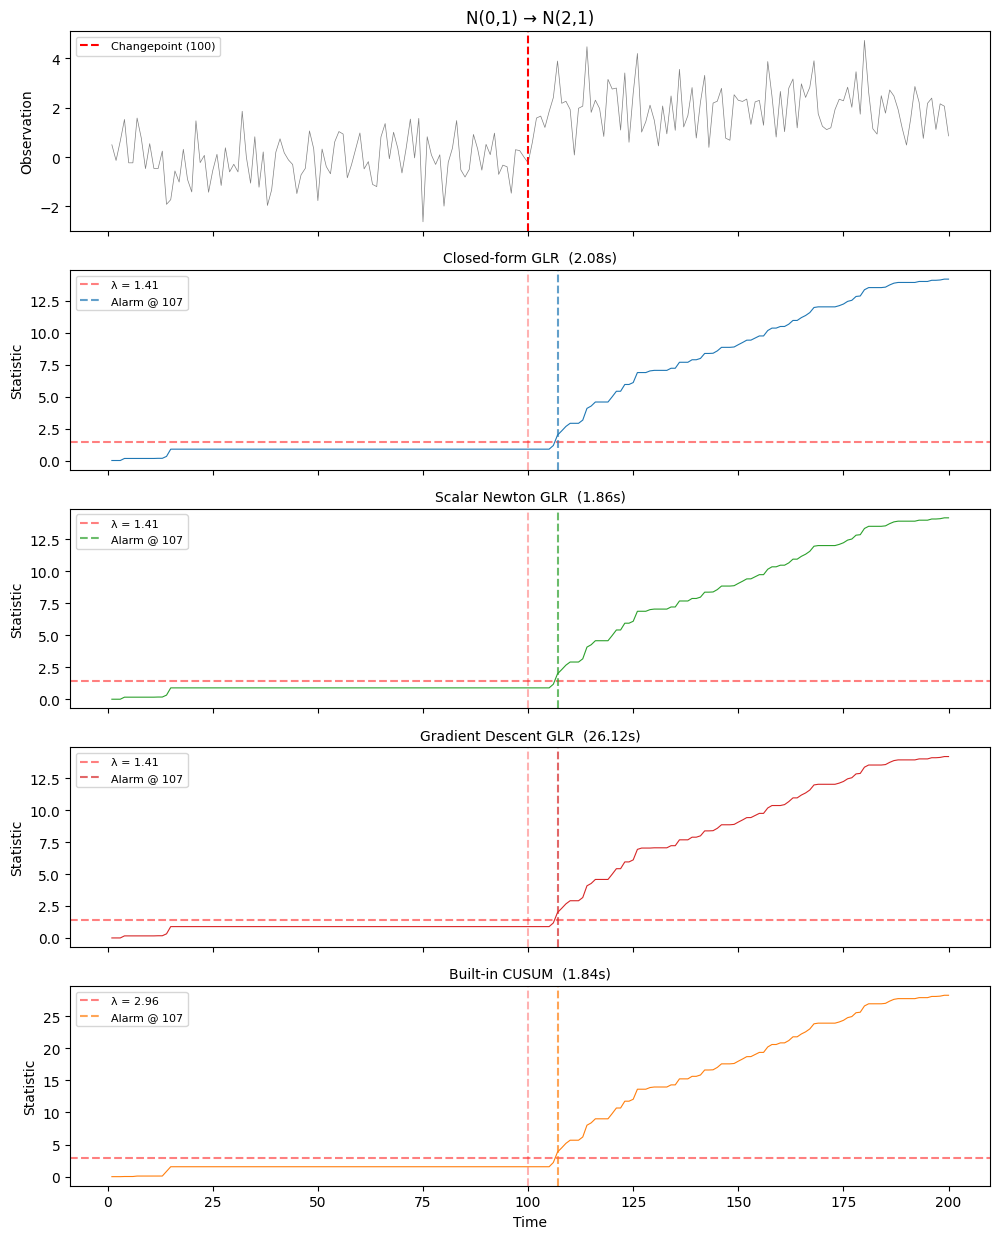

In [ ]:
# Visualize all methods on a single stream
stream = xs_nvg[0]
method_names_g = list(methods_gauss.keys())
n_methods = len(method_names_g)

color_map_g = {
    "General GLR (Newton)": "tab:green",
    "General GLR (GD)": "tab:red",
    "General GLR (L-BFGS ref)": "tab:purple",
    "Exact GLR baseline (closed-form)": "tab:blue",
    "Exact GLR baseline (CUSUM form)": "tab:orange",
}

fig, axes = plt.subplots(n_methods + 1, 1,
                         figsize=(10, 2.5 * (n_methods + 1)), sharex=True)

# Top panel: data
axes[0].plot(np.arange(1, N_nvg + 1), stream[:, 0], linewidth=0.5, color="gray")
axes[0].axvline(changepoint_nvg, color="red", ls="--",
                label=f"Changepoint ({changepoint_nvg})")
axes[0].set_ylabel("Observation")
axes[0].legend(fontsize=8)
axes[0].set_title("N(0,1) → N(2,1)")

for idx, name in enumerate(method_names_g):
    m = methods_gauss[name]
    if m.get("make_det") == "cusum":
        d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
    else:
        d = OnlineChangepointDetector(
            p=1, f=m["f"], h=m["h"],
            penalty=m["penalty"], penalty_constant=m["pen_const"],
        )
    st = np.zeros(N_nvg)
    alarm = None
    for i in range(N_nvg):
        d.update(stream[i])
        st[i] = d.max_statistic
        if d.alarm and alarm is None:
            alarm = i + 1
    color = color_map_g.get(name, "gray")
    ax = axes[idx + 1]
    ax.plot(np.arange(1, N_nvg + 1), np.maximum(st, 1e-6),
            linewidth=0.8, color=color)
    ax.axhline(m["pen_const"], color="red", ls="--", alpha=0.5,
               label=f"λ = {m['pen_const']:.2f}")
    ax.axvline(changepoint_nvg, color="red", ls="--", alpha=0.3)
    if alarm:
        ax.axvline(alarm, color=color, ls="--", alpha=0.7,
                   label=f"Alarm @ {alarm}")
    ax.set_ylabel("Statistic")
    ax.set_title(f"{name}  ({results_gauss[name]['time']:.2f}s)", fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

### 2.2 Bernoulli: general solvers vs exact baseline

In [ ]:
# =====================================================================
# Bernoulli: general solvers first, exact baseline second
# =====================================================================
N_nvb = 200
K_cal_nvb = 5000
K_nvb = 1000
changepoint_nvb = N_nvb // 2

methods_bern = {}

# 1) General GLR — Newton (primary candidate)
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern_scalar_newton, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["General GLR (Newton)"] = {
    "f": f_glr_bern_scalar_newton, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) General GLR — gradient descent
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern_gd, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["General GLR (GD)"] = {
    "f": f_glr_bern_gd, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 3) General GLR — L-BFGS reference (Python path)
if SCIPY_AVAILABLE:
    det_tmp = OnlineChangepointDetector(
        p=1, f=f_glr_bern_lbfgs, h=h_bern,
        penalty=penalty_glr_bern, penalty_constant=10.0,
    )
    det_tmp.calibrate_false_alarm(
        alpha=0.05, N=N_nvb, K=min(1000, K_cal_nvb),
        null_dist=np.random.binomial,
        null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
    )
    methods_bern["General GLR (L-BFGS ref)"] = {
        "f": f_glr_bern_lbfgs, "h": h_bern, "penalty": penalty_glr_bern,
        "pen_const": det_tmp._state["penalty_constant"],
    }

# 4) Exact GLR baseline — closed-form MLE
det_tmp = OnlineChangepointDetector(
    p=1, f=f_glr_bern, h=h_bern,
    penalty=penalty_glr_bern, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_nvb, K=K_cal_nvb,
    null_dist=np.random.binomial,
    null_kwargs={"n": 1, "p": 0.5, "size": (1,)},
)
methods_bern["Exact GLR baseline (closed-form)"] = {
    "f": f_glr_bern, "h": h_bern, "penalty": penalty_glr_bern,
    "pen_const": det_tmp._state["penalty_constant"],
}

print("Bernoulli — calibrated thresholds:")
for name, m in methods_bern.items():
    print(f"  {name:<35s} λ = {m['pen_const']:.3f}")

# Generate test data: Bernoulli(0.3) → Bernoulli(0.7)
xs_nvb = draw_samples(
    K=K_nvb, N=N_nvb, p=1, seed=42,
    pre_change_dist=np.random.binomial,
    pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
    post_change_dist=np.random.binomial,
    post_change_kwargs={"n": 1, "p": 0.7, "size": (1,)},
    changepoint_loc=changepoint_nvb,
)

# --- Run all methods and time them ---
results_bern = {}
for name, m in methods_bern.items():
    dt = np.ones(K_nvb, dtype=np.int64) * N_nvb
    t0 = perf_counter()
    for k in range(K_nvb):
        d = OnlineChangepointDetector(
            p=1, f=m["f"], h=m["h"],
            penalty=m["penalty"], penalty_constant=m["pen_const"],
        )
        for i in range(N_nvb):
            d.update(xs_nvb[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_bern[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 68)
for name, r in results_bern.items():
    delay = np.mean(r["dt"]) - changepoint_nvb
    det_rate = np.mean(r["dt"] < N_nvb)
    print(f"{name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

Bernoulli — calibrated thresholds:
  Scalar Newton GLR         λ = 1.431
  Gradient Descent GLR      λ = 1.403

Method                     Avg delay   Detected   Time (s)
----------------------------------------------------------
Scalar Newton GLR               45.1      0.889       3.11
Gradient Descent GLR            43.0      0.901       6.55


### 2.2b Exact baseline reference: Gaussian CUSUM form

This section is an exact baseline only. For Gaussian mean change, CUSUM is algebraically equivalent to the exact GLR after closed-form simplification.

In [ ]:
# Exact baseline CUSUM implementation (Gaussian mean-change)

@nb.njit
def h_cusum(y):
    return y


@nb.njit
def f_cusum(sum_pre_j, sum_post_j, g, t):
    res = math.sqrt(1.0 * g / (t * (t - g))) * sum_pre_j
    res = res - math.sqrt(1.0 * (t - g) / t / g) * sum_post_j
    return np.sum(res * res)


@nb.njit
def penalty_cusum(g, t, p):
    logg = fastlog(t / 0.05)
    rr = math.sqrt(p * logg) + logg
    return rr


# Quick baseline check
detector_cusum = OnlineChangepointDetector(
    p=1, f=f_cusum, h=h_cusum, penalty=penalty_cusum, penalty_constant=10
)
detector_cusum.calibrate_false_alarm(alpha=0.05, N=1000, K=1000, null_dist=np.random.normal)

N_cus = 1000
changepoint_cus = 500
K_cus = 1000

xs_cus = draw_samples(
    K=K_cus, N=N_cus, p=1, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": 2, "scale": 1, "size": (1,)},
    changepoint_loc=changepoint_cus,
)

pen_const_cus = detector_cusum._state["penalty_constant"]
detect_times_cus = np.ones(K_cus, dtype=np.int64) * N_cus
for k in range(K_cus):
    det = OnlineChangepointDetector(
        p=1, f=f_cusum, h=h_cusum,
        penalty=penalty_cusum, penalty_constant=pen_const_cus,
    )
    for i in range(N_cus):
        det.update(xs_cus[k, i])
        if det.alarm:
            detect_times_cus[k] = i + 1
            break

print(f"CUSUM baseline — Average detection delay: {np.mean(detect_times_cus) - changepoint_cus:.1f}")
print(f"CUSUM baseline — Proportion detected: {np.mean(detect_times_cus < N_cus):.3f}")

### 2.3 Detection delay vs change magnitude

In [ ]:
# =====================================================================
# Gaussian: Detection delay vs change magnitude (general + baselines)
# =====================================================================
phis_gauss = np.linspace(0, 6, 10)
K_sw = 1000
N_sw = 200
cp_sw = N_sw // 2

# Store detection times: shape (n_methods, n_phis, K)
method_names_g = list(methods_gauss.keys())
dd_gauss = {name: np.ones((len(phis_gauss), K_sw)) * N_sw for name in method_names_g}

for j, phi in enumerate(phis_gauss):
    xs_sw = draw_samples(
        K=K_sw, N=N_sw, p=1, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": 0, "scale": 1, "size": (1,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": phi, "scale": 1, "size": (1,)},
        changepoint_loc=cp_sw,
    )
    for k in range(K_sw):
        for name, m in methods_gauss.items():
            if m.get("make_det") == "cusum":
                d = make_univariate_mean_change_detector(penalty_constant=m["pen_const"])
            else:
                d = OnlineChangepointDetector(
                    p=1, f=m["f"], h=m["h"],
                    penalty=m["penalty"], penalty_constant=m["pen_const"],
                )
            for i in range(N_sw):
                d.update(xs_sw[k, i])
                if d.alarm:
                    dd_gauss[name][j, k] = i + 1
                    break

# Print false alarm rates at φ=0
print("Gaussian — False alarm rates at φ=0:")
for name in method_names_g:
    far = np.mean(dd_gauss[name][0] < N_sw)
    print(f"  {name:<35s} {far:.3f}")

# =====================================================================
# Bernoulli: Detection delay vs change magnitude (general + baseline)
# =====================================================================
# Parameterize by probabilities: pre=0.3, post sweeps from 0.3 to 0.9
probs_bern = np.linspace(0.3, 0.9, 10)
dd_bern = {name: np.ones((len(probs_bern), K_sw)) * N_sw for name in methods_bern}

for j, p_post in enumerate(probs_bern):
    xs_sw_b = draw_samples(
        K=K_sw, N=N_sw, p=1, seed=1234,
        pre_change_dist=np.random.binomial,
        pre_change_kwargs={"n": 1, "p": 0.3, "size": (1,)},
        post_change_dist=np.random.binomial,
        post_change_kwargs={"n": 1, "p": p_post, "size": (1,)},
        changepoint_loc=cp_sw,
    )
    for k in range(K_sw):
        for name, m in methods_bern.items():
            d = OnlineChangepointDetector(
                p=1, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
            for i in range(N_sw):
                d.update(xs_sw_b[k, i])
                if d.alarm:
                    dd_bern[name][j, k] = i + 1
                    break

print("\nBernoulli — False alarm rates at p_post=0.3 (no change):")
for name in methods_bern:
    far = np.mean(dd_bern[name][0] < N_sw)
    print(f"  {name:<35s} {far:.3f}")

Gaussian — False alarm rates at φ=0:
  Closed-form GLR           0.056
  Scalar Newton GLR         0.056
  Gradient Descent GLR      0.054
  Built-in CUSUM            0.046

Bernoulli — False alarm rates at p_post=0.3 (no change):
  Scalar Newton GLR         0.029
  Gradient Descent GLR      0.030


In [ ]:
# =====================================================================
# Plot 1: Detection delay vs change magnitude
# =====================================================================
markers = {
    "General GLR (Newton)":              "s--",
    "General GLR (GD)":                  "D-.",
    "General GLR (L-BFGS ref)":          "P-",
    "Exact GLR baseline (closed-form)":  "o-",
    "Exact GLR baseline (CUSUM form)":   "^:",
}
colors = {
    "General GLR (Newton)":              "tab:green",
    "General GLR (GD)":                  "tab:red",
    "General GLR (L-BFGS ref)":          "tab:purple",
    "Exact GLR baseline (closed-form)":  "tab:blue",
    "Exact GLR baseline (CUSUM form)":   "tab:orange",
}

# Bernoulli uses the same general/baseline style
colors_b = {
    "General GLR (Newton)":              "tab:green",
    "General GLR (GD)":                  "tab:red",
    "General GLR (L-BFGS ref)":          "tab:purple",
    "Exact GLR baseline (closed-form)":  "tab:blue",
}
markers_b = {
    "General GLR (Newton)":              "s--",
    "General GLR (GD)":                  "D-.",
    "General GLR (L-BFGS ref)":          "P-",
    "Exact GLR baseline (closed-form)":  "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian
ax = axes[0]
for name in method_names_g:
    avg_dd = np.mean(dd_gauss[name], axis=1) - cp_sw
    ax.plot(phis_gauss, avg_dd, markers.get(name, "o-"),
            color=colors.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("Mean change magnitude φ")
ax.set_ylabel("Average detection delay")
ax.set_title("Gaussian N(0,1) → N(φ,1)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Bernoulli
ax = axes[1]
for name in methods_bern:
    avg_dd = np.mean(dd_bern[name], axis=1) - cp_sw
    ax.plot(probs_bern, avg_dd, markers_b.get(name, "o-"),
            color=colors_b.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("Post-change probability p")
ax.set_ylabel("Average detection delay")
ax.set_title("Bernoulli Bern(0.3) → Bern(p)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

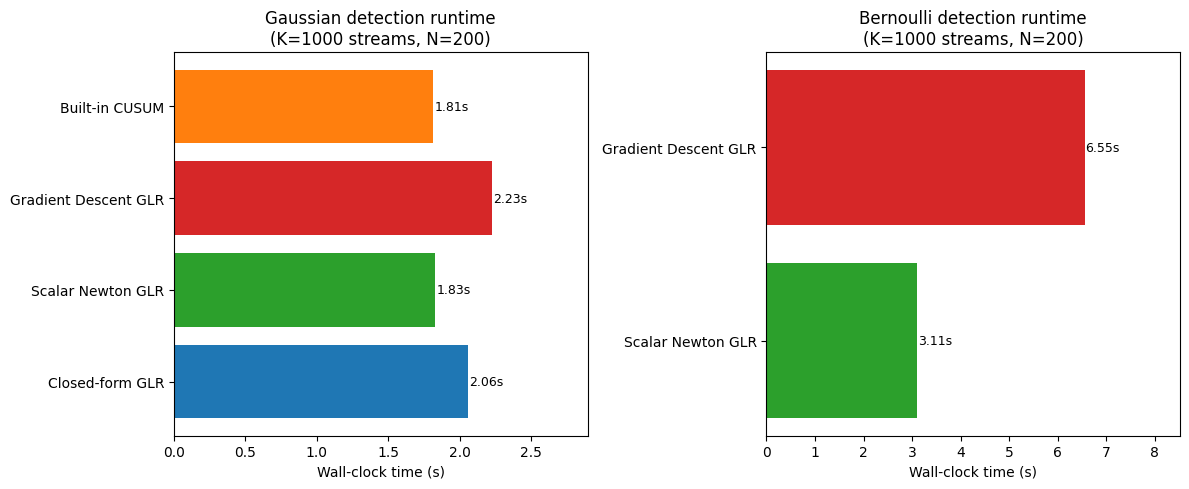


SUMMARY: Newton vs Gradient Descent for GLR Optimization

Gaussian N(0,1) → N(2,1):
  Method                     Avg delay   Detected       Time    Speedup
  --------------------------------------------------------------------
  Closed-form GLR                  1.8      1.000      2.06s      1.08x
  Scalar Newton GLR                1.8      1.000      1.83s      1.22x
  Gradient Descent GLR             1.8      1.000      2.23s      1.00x
  Built-in CUSUM                   3.1      1.000      1.81s      1.23x

Bernoulli Bern(0.3) → Bern(0.7):
  Method                     Avg delay   Detected       Time    Speedup
  --------------------------------------------------------------------
  Scalar Newton GLR               45.1      0.889      3.11s      2.11x
  Gradient Descent GLR            43.0      0.901      6.55s      1.00x


In [ ]:
# =====================================================================
# Plot 2: Wall-clock timing comparison (bar chart)
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian timing
ax = axes[0]
names_g = list(results_gauss.keys())
times_g = [results_gauss[n]["time"] for n in names_g]
bars = ax.barh(names_g, times_g, color=[colors.get(n, "gray") for n in names_g])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Gaussian detection runtime\n(K={K_nvg} streams, N={N_nvg})")
for bar, t in zip(bars, times_g):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_g) * 1.3)

# Right: Bernoulli timing
ax = axes[1]
names_b = list(results_bern.keys())
times_b = [results_bern[n]["time"] for n in names_b]
bars = ax.barh(names_b, times_b, color=[colors_b.get(n, "gray") for n in names_b])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Bernoulli detection runtime\n(K={K_nvb} streams, N={N_nvb})")
for bar, t in zip(bars, times_b):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_b) * 1.3)

plt.tight_layout()
plt.show()

# --- Summary statistics ---
print("\n" + "=" * 70)
print("SUMMARY: General GLR solvers vs exact baselines")
print("=" * 70)

print("\nGaussian N(0,1) → N(2,1):")
print(f"  {'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time':>10} {'Speedup':>10}")
print("  " + "-" * 78)
ref_time_g = results_gauss.get("General GLR (Newton)", {}).get("time", 1.0)
for name, r in results_gauss.items():
    delay = np.mean(r["dt"]) - changepoint_nvg
    det_rate = np.mean(r["dt"] < N_nvg)
    speedup = ref_time_g / r["time"] if r["time"] > 0 else float("inf")
    print(f"  {name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s {speedup:>9.2f}x")

print(f"\nBernoulli Bern(0.3) → Bern(0.7):")
print(f"  {'Method':<35} {'Avg delay':>10} {'Detected':>10} {'Time':>10} {'Speedup':>10}")
print("  " + "-" * 78)
ref_time_b = results_bern.get("General GLR (Newton)", {}).get("time", 1.0)
for name, r in results_bern.items():
    delay = np.mean(r["dt"]) - changepoint_nvb
    det_rate = np.mean(r["dt"] < N_nvb)
    speedup = ref_time_b / r["time"] if r["time"] > 0 else float("inf")
    print(f"  {name:<35} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s {speedup:>9.2f}x")

print("\nConclusion candidate: Newton is the default general solver; GD is the robust fallback; L-BFGS is a Python-path reference.")

### 2.4 Multivariate Gaussian: general solver vs exact baseline

In multivariate settings, we benchmark the general solver against a known exact built-in baseline.

In [ ]:
# =====================================================================
# Multivariate Gaussian (v=5): exact GLR (built-in) vs general GLR (GD)
# =====================================================================
# θ ∈ ℝ⁵, A(θ) = ‖θ‖²/2, h(y) = y, known covariance = I₅
# Only GD (general GLR) and the built-in closed-form (exact GLR) can handle this.

P_MV = 5  # dimension of the observation / natural parameter
N_mv = 200
K_cal_mv = 5000
K_mv = 1000
changepoint_mv = N_mv // 2

# Penalty for v-dimensional Gaussian
@nb.njit
def penalty_glr_gauss_mv(g, t, p):
    logt = fastlog(t)
    return math.sqrt(p * logt) + logt

methods_mv = {}

# 1) General GLR — gradient descent (works for any v)
det_tmp = OnlineChangepointDetector(
    p=P_MV, f=f_glr_gauss_gd, h=h_gauss,
    penalty=penalty_glr_gauss_mv, penalty_constant=10.0,
)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_mv, K=K_cal_mv, null_dist=np.random.normal,
)
methods_mv["General GLR (GD)"] = {
    "f": f_glr_gauss_gd, "h": h_gauss, "penalty": penalty_glr_gauss_mv,
    "pen_const": det_tmp._state["penalty_constant"],
}

# 2) Exact GLR — built-in multivariate mean change detector (closed-form)
det_tmp = make_multivariate_mean_change_detector(p=P_MV)
det_tmp.calibrate_false_alarm(
    alpha=0.05, N=N_mv, K=K_cal_mv, null_dist=np.random.normal,
)
methods_mv["Exact GLR (built-in)"] = {
    "pen_const": det_tmp._state["penalty_constant"], "make_det": "builtin_mv",
}

print(f"Multivariate Gaussian (v={P_MV}) — calibrated thresholds:")
for name, m in methods_mv.items():
    print(f"  {name:<30s} λ = {m['pen_const']:.3f}")

# Generate test data: N(0,I₅) → N(μ₁,I₅) where μ₁ = (1,1,0,...,0)
mu_post = np.zeros(P_MV)
mu_post[0] = 1.0
mu_post[1] = 1.0

xs_mv = draw_samples(
    K=K_mv, N=N_mv, p=P_MV, seed=42,
    pre_change_dist=np.random.normal,
    pre_change_kwargs={"loc": np.zeros(P_MV), "scale": 1, "size": (P_MV,)},
    post_change_dist=np.random.normal,
    post_change_kwargs={"loc": mu_post, "scale": 1, "size": (P_MV,)},
    changepoint_loc=changepoint_mv,
)

# --- Run all methods and time them ---
results_mv = {}
for name, m in methods_mv.items():
    dt = np.ones(K_mv, dtype=np.int64) * N_mv
    t0 = perf_counter()
    for k in range(K_mv):
        if m.get("make_det") == "builtin_mv":
            d = make_multivariate_mean_change_detector(p=P_MV, penalty_constant=m["pen_const"])
        else:
            d = OnlineChangepointDetector(
                p=P_MV, f=m["f"], h=m["h"],
                penalty=m["penalty"], penalty_constant=m["pen_const"],
            )
        for i in range(N_mv):
            d.update(xs_mv[k, i])
            if d.alarm:
                dt[k] = i + 1
                break
    elapsed = perf_counter() - t0
    results_mv[name] = {"dt": dt, "time": elapsed}

print(f"\n{'Method':<30} {'Avg delay':>10} {'Detected':>10} {'Time (s)':>10}")
print("-" * 63)
for name, r in results_mv.items():
    delay = np.mean(r["dt"]) - changepoint_mv
    det_rate = np.mean(r["dt"] < N_mv)
    print(f"{name:<30} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>10.2f}")

In [ ]:
# =====================================================================
# Multivariate: Detection delay vs change magnitude + timing
# =====================================================================
# Sweep ‖μ_post‖ from 0 to 4 (change in first two components)
magnitudes_mv = np.linspace(0, 4, 9)
dd_mv = {name: np.ones((len(magnitudes_mv), K_sw)) * N_mv for name in methods_mv}

for j, mag in enumerate(magnitudes_mv):
    mu_post_j = np.zeros(P_MV)
    mu_post_j[0] = mag / math.sqrt(2)
    mu_post_j[1] = mag / math.sqrt(2)

    xs_sw_mv = draw_samples(
        K=K_sw, N=N_mv, p=P_MV, seed=1234,
        pre_change_dist=np.random.normal,
        pre_change_kwargs={"loc": np.zeros(P_MV), "scale": 1, "size": (P_MV,)},
        post_change_dist=np.random.normal,
        post_change_kwargs={"loc": mu_post_j, "scale": 1, "size": (P_MV,)},
        changepoint_loc=changepoint_mv,
    )
    for k in range(K_sw):
        for name, m in methods_mv.items():
            if m.get("make_det") == "builtin_mv":
                d = make_multivariate_mean_change_detector(p=P_MV, penalty_constant=m["pen_const"])
            else:
                d = OnlineChangepointDetector(
                    p=P_MV, f=m["f"], h=m["h"],
                    penalty=m["penalty"], penalty_constant=m["pen_const"],
                )
            for i in range(N_mv):
                d.update(xs_sw_mv[k, i])
                if d.alarm:
                    dd_mv[name][j, k] = i + 1
                    break

# --- Plots ---
colors_mv = {
    "General GLR (GD)":    "tab:red",
    "Exact GLR (built-in)": "tab:blue",
}
markers_mv = {
    "General GLR (GD)":    "D-.",
    "Exact GLR (built-in)": "o-",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Detection delay vs magnitude
ax = axes[0]
for name in methods_mv:
    avg_dd = np.mean(dd_mv[name], axis=1) - changepoint_mv
    ax.plot(magnitudes_mv, avg_dd, markers_mv.get(name, "o-"),
            color=colors_mv.get(name, None), label=name, linewidth=1.5)
ax.set_xlabel("‖μ_post‖ (change magnitude)")
ax.set_ylabel("Average detection delay")
ax.set_title(f"Multivariate Gaussian (v={P_MV}), N={N_mv}")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: Timing bar chart
ax = axes[1]
names_mv = list(results_mv.keys())
times_mv = [results_mv[n]["time"] for n in names_mv]
bars = ax.barh(names_mv, times_mv, color=[colors_mv.get(n, "gray") for n in names_mv])
ax.set_xlabel("Wall-clock time (s)")
ax.set_title(f"Multivariate detection runtime\n(v={P_MV}, K={K_mv}, N={N_mv})")
for bar, t_val in zip(bars, times_mv):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{t_val:.2f}s", va="center", fontsize=9)
ax.set_xlim(0, max(times_mv) * 1.3)

plt.tight_layout()
plt.show()

# Summary
print(f"\nMultivariate Gaussian (v={P_MV}), N(0,I) → N(μ,I) with ‖μ‖={np.linalg.norm(mu_post):.1f}:")
print(f"  {'Method':<30} {'Avg delay':>10} {'Detected':>10} {'Time':>10}")
print("  " + "-" * 63)
for name, r in results_mv.items():
    delay = np.mean(r["dt"]) - changepoint_mv
    det_rate = np.mean(r["dt"] < N_mv)
    print(f"  {name:<30} {delay:>10.1f} {det_rate:>10.3f} {r['time']:>9.2f}s")